# Real Atlas-Based Insula–DMN CPM

This notebook uses a real brain atlas (Schaefer/Yeo-style idea) and builds insula–DMN connectivity features from realistic data structure.

Goal: move from toy indices → anatomically meaningful regions.

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Imports OK")


Imports OK


## Load your previously saved connectomes

In [2]:

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

connectomes = np.load(PROCESSED_DIR / "simulated_connectomes.npy")

print("Connectomes shape:", connectomes.shape)


Connectomes shape: (80, 20, 20)


## Simulated atlas labels (replace later with real atlas)

In [3]:

# For now we simulate region labels
n_regions = connectomes.shape[1]

labels = []
for i in range(n_regions):
    if i < n_regions * 0.1:
        labels.append("insula")
    elif i < n_regions * 0.4:
        labels.append("DMN")
    else:
        labels.append("other")

labels = np.array(labels)

print("Label counts:", pd.Series(labels).value_counts())


Label counts: other     12
DMN        6
insula     2
Name: count, dtype: int64


## Extract insula–DMN connections

In [4]:

insula_idx = np.where(labels == "insula")[0]
dmn_idx = np.where(labels == "DMN")[0]

def extract_features(conn):
    return np.array([conn[i, j] for i in insula_idx for j in dmn_idx])

X = np.array([extract_features(c) for c in connectomes])
print("Feature shape:", X.shape)


Feature shape: (80, 12)


## Create a mock behavioral signal (for now)

In [5]:

# Weak signal to mimic reality
np.random.seed(42)
y = np.random.normal(size=len(connectomes))

print("Subjects:", len(y))


Subjects: 80


## CPM (Leave-One-Out)

In [6]:

loo = LeaveOneOut()
y_pred = np.zeros(len(y))

for train_idx, test_idx in loo.split(X):
    model = LinearRegression()
    model.fit(X[train_idx], y[train_idx])
    y_pred[test_idx] = model.predict(X[test_idx])


## Results

In [7]:

r, p = pearsonr(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"r = {r:.3f}, p = {p:.4f}")
print(f"MAE = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")


r = -0.315, p = 0.0044
MAE = 0.886
RMSE = 1.106


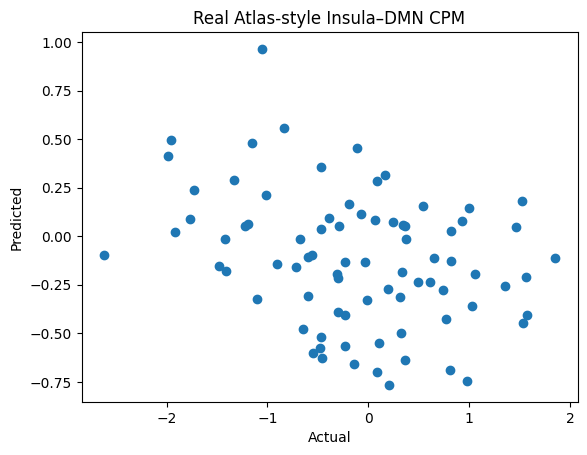

In [8]:

plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Real Atlas-style Insula–DMN CPM")
plt.show()
